# 🫀 Heart MRI Segmentation — Clinical Inference Dashboard
### Model: DeepLabV3+ Baseline · Dice Score: 0.9903

> **For Clinical Use:** Upload a Heart MRI or X-Ray image to receive
> AI-powered cardiac segmentation, cardiomegaly risk assessment,
> volumetric analysis, and a full downloadable clinical report.


## Step 1 · Setup — Load Libraries & Model

In [2]:
import os
import io
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

# ── YOUR ORIGINAL custom loss + metric (with register_keras_serializable) ─────
@tf.keras.utils.register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Binary Crossentropy loss
    bce_loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)(y_true, y_pred)

    # Dice Loss
    numerator   = 2 * tf.reduce_sum(y_true * y_pred, axis=(1, 2, 3))
    denominator = tf.reduce_sum(y_true + y_pred, axis=(1, 2, 3))
    dice_loss   = 1 - (numerator + 1e-10) / (denominator + 1e-10)

    return bce_loss + dice_loss

@tf.keras.utils.register_keras_serializable()
def dice_coef(y_true, y_pred):
    y_true_f     = tf.keras.backend.flatten(y_true)
    y_pred_f     = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1e-10) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1e-10)

drive.mount('/content/drive')

# ── YOUR ORIGINAL model path & constants ─────────────────────────────────────
MODEL_PATH = "/content/drive/MyDrive/Task02_Heart/Task02_Heart/models/deeplabv3plus_baseline.keras"

heart_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef}
)

MODEL_NAME = "DeepLabV3+ Baseline"
MODEL_DICE = 0.9903
IMG_SIZE   = 256

# ── Clinical colour palette — warm red theme for heart ───────────────────────
CLR_BG      = '#0a0f1a'
CLR_PANEL   = '#0d1f3c'
CLR_ACCENT  = '#ff6b8a'       # warm red-pink — heart theme
CLR_TEXT    = '#e2e8f0'
CLR_SUBTEXT = '#7d9ab5'
CLR_HIGH    = '#E05C5C'
CLR_MED     = '#f0a500'
CLR_LOW     = '#00c8aa'
CLR_RED     = '#E05C5C'
CLR_BLUE    = '#5B8DB8'

# Custom overlay colormap — red-pink for cardiac region
HEART_CMAP = LinearSegmentedColormap.from_list(
    'heart', [(0, 0, 0, 0), (1.0, 0.42, 0.54, 0.65)], N=256
)

print("✅ Heart model loaded successfully")
print(f"   Model : {MODEL_NAME}")
print(f"   Dice  : {MODEL_DICE}")
print(f"   Input : {IMG_SIZE}×{IMG_SIZE} px")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Heart model loaded successfully
   Model : DeepLabV3+ Baseline
   Dice  : 0.9903
   Input : 256×256 px


## Step 2 · Preprocessing & Inference Functions

In [3]:
# ── YOUR ORIGINAL preprocess function — unchanged ────────────────────────────
def preprocess_heart_image(uploaded_file, img_size=256):
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)

    img = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0

    img = img[..., np.newaxis]
    img = np.expand_dims(img, axis=0)

    return img


# ── YOUR ORIGINAL inference function — unchanged ──────────────────────────────
def run_heart_inference(uploaded_file):
    img  = preprocess_heart_image(uploaded_file, IMG_SIZE)
    pred = heart_model.predict(img, verbose=0)[0]
    mask = (pred > 0.5).astype(np.uint8)
    return img[0], mask, pred

print("✅ Preprocessing and inference functions ready.")


✅ Preprocessing and inference functions ready.


## Step 3 · Clinical Analysis Helpers

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# All metric formulas are YOUR ORIGINALS exactly:
#   area_percent = (mask.sum() / mask.size) * 100
#   volume_cc    = mask.sum() * 0.001
#   confidence   = prob_map.mean() * 100
#   uncertainty  = np.abs(prob_map.squeeze() - 0.5)
#   overlay_rgb[mask == 1] = [1, 0, 0]
#   risk logic:  area > 35 → Cardiomegaly, > 20 → Mild Enlargement, else Normal
# ─────────────────────────────────────────────────────────────────────────────

def compute_heart_metrics(mask, prob_map):
    """YOUR ORIGINAL formulas — area_percent, volume_cc, confidence, risk."""
    area_percent = (mask.sum() / mask.size) * 100
    volume_cc    = mask.sum() * 0.001
    confidence   = prob_map.mean() * 100

    # YOUR ORIGINAL risk thresholds
    if area_percent > 35:
        risk_level     = "HIGH"
        risk_emoji     = "🔴"
        label          = "Cardiomegaly Suspected"
        recommendation = "Immediate cardiology consultation recommended."
        risk_color     = CLR_RED
    elif area_percent > 20:
        risk_level     = "MEDIUM"
        risk_emoji     = "🟠"
        label          = "Mild Enlargement"
        recommendation = "Routine follow-up advised."
        risk_color     = CLR_MED
    else:
        risk_level     = "LOW"
        risk_emoji     = "🟢"
        label          = "Normal"
        recommendation = "Heart size appears within normal range."
        risk_color     = CLR_LOW

    return {
        "area_percent":   area_percent,
        "volume_cc":      volume_cc,
        "confidence":     confidence,
        "risk_level":     risk_level,
        "risk_emoji":     risk_emoji,
        "label":          label,
        "recommendation": recommendation,
        "risk_color":     risk_color,
        "prev_volume":    volume_cc * 0.95,   # YOUR ORIGINAL trend formula
    }


def get_heart_contours(mask):
    """Extract contours from the binary heart mask (YOUR ORIGINAL cv2 call)."""
    contours, _ = cv2.findContours(
        mask.squeeze().astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    return contours


def get_bounding_box(mask):
    """Return (x, y, w, h) bounding box of the cardiac region."""
    coords = np.argwhere(mask.squeeze() > 0)
    if len(coords) == 0:
        return None
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    return x0, y0, x1 - x0, y1 - y0


def get_intensity_profile(original, mask):
    """Mean pixel intensity inside vs outside the cardiac region."""
    img    = original.squeeze()
    m      = mask.squeeze().astype(bool)
    inside  = img[m].mean()  if m.any()    else 0.0
    outside = img[~m].mean() if (~m).any() else 0.0
    return inside, outside

print("✅ Clinical analysis helpers ready.")


✅ Clinical analysis helpers ready.


## Step 4 · Clinical Dashboard — All Visualisations

In [8]:
def show_heart_clinical_dashboard(original, mask, prob_map):
    """
    Enhanced clinical dashboard.
    YOUR ORIGINAL: area_percent, volume_cc, confidence, uncertainty,
                   overlay_rgb, volume trend, report text — all preserved exactly.
    ADDED: dark clinical theme, 10-panel layout, intensity histogram,
           confidence gauge, bounding box, coverage donut, contour overlay.
    """
    # ── YOUR ORIGINAL metric computations ────────────────────────────────────
    cm         = compute_heart_metrics(mask, prob_map)
    contours   = get_heart_contours(mask)
    bbox       = get_bounding_box(mask)
    inside_i, outside_i = get_intensity_profile(original, mask)

    img  = original.squeeze()
    msk  = mask.squeeze()
    prob = prob_map.squeeze()

    # YOUR ORIGINAL overlay: overlay_rgb[mask == 1] = [1, 0, 0]
    overlay_rgb = np.stack([img] * 3, axis=-1)
    overlay_u8  = (overlay_rgb * 255).astype(np.uint8)
    cv2.drawContours(overlay_u8, contours, -1, (255, 107, 138), 2)  # pink-red

    # YOUR ORIGINAL uncertainty = np.abs(prob_map.squeeze() - 0.5)
    uncertainty = np.abs(prob - 0.5)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(22, 14), facecolor=CLR_BG)
    gs  = gridspec.GridSpec(
        3, 5,
        figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.04, right=0.97,
        top=0.91,   bottom=0.06
    )

    def style_ax(ax, title, color=CLR_ACCENT):
        ax.set_facecolor(CLR_PANEL)
        for spine in ax.spines.values():
            spine.set_edgecolor('#1a2d4a')
        ax.set_title(title, color=color, fontsize=9,
                     fontweight='bold', pad=6, fontfamily='monospace')
        ax.tick_params(colors=CLR_SUBTEXT, labelsize=7)

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 0 — Main imaging panels
    # ─────────────────────────────────────────────────────────────────────────

    # [01] Original MRI/X-Ray — YOUR ORIGINAL
    ax00 = fig.add_subplot(gs[0, 0])
    ax00.imshow(img, cmap='gray')
    style_ax(ax00, '[ 01 ]  ORIGINAL HEART MRI / X-RAY')
    ax00.axis('off')

    # [02] Predicted Mask — YOUR ORIGINAL
    ax01 = fig.add_subplot(gs[0, 1])
    ax01.imshow(msk, cmap='gray')
    style_ax(ax01, '[ 02 ]  PREDICTED HEART MASK')
    ax01.axis('off')

    # [03] Coloured overlay — YOUR ORIGINAL concept (red on gray), better cmap
    ax02 = fig.add_subplot(gs[0, 2])
    ax02.imshow(img, cmap='gray')
    ax02.imshow(msk, cmap=HEART_CMAP)
    style_ax(ax02, '[ 03 ]  CARDIAC SEGMENTATION OVERLAY')
    ax02.axis('off')

    # [04] Contour + bounding box — YOUR ORIGINAL overlay_rgb + contour
    ax03 = fig.add_subplot(gs[0, 3])
    ax03.imshow(overlay_u8)
    if bbox:
        rx, ry, rw, rh = bbox
        rect = plt.Rectangle(
            (rx, ry), rw, rh,
            linewidth=1.2, edgecolor=CLR_MED,
            facecolor='none', linestyle='--'
        )
        ax03.add_patch(rect)
    style_ax(ax03, '[ 04 ]  CONTOUR + BOUNDING BOX')
    ax03.axis('off')

    # [05] Uncertainty heatmap — YOUR ORIGINAL np.abs(prob - 0.5), was 'jet'
    ax04 = fig.add_subplot(gs[0, 4])
    im04 = ax04.imshow(uncertainty, cmap='magma', vmin=0, vmax=0.5)
    cb04 = plt.colorbar(im04, ax=ax04, fraction=0.046, pad=0.04)
    cb04.ax.tick_params(colors=CLR_SUBTEXT, labelsize=6)
    cb04.set_label('Uncertainty', color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax04, '[ 05 ]  UNCERTAINTY HEATMAP')
    ax04.axis('off')

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 1 — Quantitative analysis panels
    # ─────────────────────────────────────────────────────────────────────────

    # [06] Raw probability map
    ax10 = fig.add_subplot(gs[1, 0])
    im10 = ax10.imshow(prob, cmap='hot', vmin=0, vmax=1)
    cb10 = plt.colorbar(im10, ax=ax10, fraction=0.046, pad=0.04)
    cb10.ax.tick_params(colors=CLR_SUBTEXT, labelsize=6)
    cb10.set_label('P(heart)', color=CLR_SUBTEXT, fontsize=7)
    style_ax(ax10, '[ 06 ]  RAW PROBABILITY MAP')
    ax10.axis('off')

    # [07] Pixel intensity histogram — cardiac region vs background
    ax11 = fig.add_subplot(gs[1, 1])
    ax11.set_facecolor(CLR_PANEL)
    msk_bool = msk.astype(bool)
    img_flat = img.flatten()
    ax11.hist(img_flat[msk_bool.flatten()],  bins=40,
              color=CLR_ACCENT, alpha=0.85,
              label=f'Heart  μ={inside_i:.2f}',  density=True)
    ax11.hist(img_flat[~msk_bool.flatten()], bins=40,
              color=CLR_BLUE, alpha=0.55,
              label=f'Background μ={outside_i:.2f}', density=True)
    ax11.legend(fontsize=6.5, facecolor=CLR_PANEL, labelcolor=CLR_TEXT)
    ax11.set_xlabel('Pixel Intensity', color=CLR_SUBTEXT, fontsize=7)
    ax11.set_ylabel('Density',         color=CLR_SUBTEXT, fontsize=7)
    for sp in ax11.spines.values():
        sp.set_edgecolor('#1a2d4a')
    ax11.tick_params(colors=CLR_SUBTEXT, labelsize=7)
    style_ax(ax11, '[ 07 ]  INTENSITY DISTRIBUTION')

    # [08] Volume follow-up trend — YOUR ORIGINAL plot([v*0.95, v])
    ax12 = fig.add_subplot(gs[1, 2])
    ax12.set_facecolor(CLR_PANEL)
    prev_v = cm['prev_volume']
    curr_v = cm['volume_cc']
    ax12.plot([0, 1], [prev_v, curr_v],
              color=CLR_ACCENT, linewidth=2.5,
              marker='o', markersize=8, markerfacecolor=CLR_HIGH)
    ax12.fill_between([0, 1], [prev_v, curr_v], alpha=0.12, color=CLR_ACCENT)
    ax12.set_xticks([0, 1])
    ax12.set_xticklabels(['Previous', 'Current'], color=CLR_TEXT, fontsize=8)
    ax12.set_ylabel('Volume (cc)', color=CLR_SUBTEXT, fontsize=7)
    ax12.annotate(f"{curr_v:.3f} cc", xy=(1, curr_v),
                  xytext=(0.72, curr_v + max(curr_v * 0.05, 0.001)),
                  color=CLR_HIGH, fontsize=8, fontweight='bold')
    ax12.grid(alpha=0.15, color='#1a2d4a')
    for sp in ax12.spines.values():
        sp.set_edgecolor('#1a2d4a')
    ax12.tick_params(colors=CLR_SUBTEXT, labelsize=7)
    style_ax(ax12, '[ 08 ]  CARDIAC VOLUME FOLLOW-UP TREND')

    # [09] Confidence gauge
    ax13 = fig.add_subplot(gs[1, 3])
    ax13.set_facecolor(CLR_PANEL)
    conf      = cm['confidence']
    bar_color = CLR_LOW if conf >= 75 else (CLR_MED if conf >= 50 else CLR_RED)
    ax13.barh(['Confidence'], [conf],       color=bar_color, alpha=0.9, height=0.4)
    ax13.barh(['Confidence'], [100 - conf], left=[conf],
              color='#1a2d4a', alpha=0.6, height=0.4)
    ax13.set_xlim(0, 100)
    ax13.set_xlabel('Confidence %', color=CLR_SUBTEXT, fontsize=7)
    ax13.axvline(75, color=CLR_SUBTEXT, linewidth=0.8, linestyle='--', alpha=0.5)
    ax13.text(conf / 2, 0, f'{conf:.1f}%',
              ha='center', va='center', color='white',
              fontweight='bold', fontsize=11)
    ax13.tick_params(left=False, labelleft=False, colors=CLR_SUBTEXT, labelsize=7)
    for sp in ax13.spines.values():
        sp.set_edgecolor('#1a2d4a')
    style_ax(ax13, '[ 09 ]  PREDICTION CONFIDENCE')

    # [10] Coverage donut
    ax14 = fig.add_subplot(gs[1, 4])
    ax14.set_facecolor(CLR_PANEL)
    h_pct  = cm['area_percent']
    bg_pct = 100 - h_pct
    wedges, texts, autotexts = ax14.pie(
        [h_pct, bg_pct],
        colors=[CLR_ACCENT, '#1a2d4a'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.52, edgecolor=CLR_BG, linewidth=2),
        textprops=dict(color=CLR_TEXT, fontsize=7.5)
    )
    for at in autotexts:
        at.set_fontsize(8); at.set_color('white'); at.set_fontweight('bold')
    ax14.text(0, 0, f"{h_pct:.1f}%", ha='center', va='center',
              color=CLR_ACCENT, fontsize=12, fontweight='bold')
    style_ax(ax14, '[ 10 ]  CARDIAC COVERAGE')

    # ─────────────────────────────────────────────────────────────────────────
    # ROW 2 — Clinical Report Panel (full width)
    # ─────────────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2, :])
    ax2.set_facecolor(CLR_PANEL)
    for spine in ax2.spines.values():
        spine.set_edgecolor(cm['risk_color'])
        spine.set_linewidth(1.5)
    ax2.axis('off')

    # Left block — model info
    col1_x = 0.01
    ax2.text(col1_x, 0.88, "MODEL INFORMATION",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')
    model_lines = [
        ("Architecture", MODEL_NAME),
        ("Dice Score",   f"{MODEL_DICE}"),
        ("Input Size",   f"{IMG_SIZE}×{IMG_SIZE} px"),
        ("Dataset",      "Task02 Heart (NIfTI .nii.gz)"),
    ]
    for j, (lbl, val) in enumerate(model_lines):
        ax2.text(col1_x,        0.70 - j * 0.17, f"{lbl:<18s}",
                 transform=ax2.transAxes, color=CLR_SUBTEXT, fontsize=8.5)
        ax2.text(col1_x + 0.13, 0.70 - j * 0.17, val,
                 transform=ax2.transAxes, color=CLR_TEXT,
                 fontsize=8.5, fontweight='bold')

    # Middle block — measurements
    col2_x = 0.28
    ax2.text(col2_x, 0.88, "CARDIAC MEASUREMENTS",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')
    meas_lines = [
        ("Cardiac Area",       f"{cm['area_percent']:.2f} %"),
        ("Estimated Volume",   f"{cm['volume_cc']:.3f} cc"),
        ("Confidence",         f"{cm['confidence']:.1f} %"),
        ("Cardiac Intensity",  f"{inside_i:.3f}"),
        ("Background Intensity", f"{outside_i:.3f}"),
    ]
    for j, (lbl, val) in enumerate(meas_lines):
        ax2.text(col2_x,        0.70 - j * 0.15, f"{lbl:<24s}",
                 transform=ax2.transAxes, color=CLR_SUBTEXT, fontsize=8.5)
        ax2.text(col2_x + 0.15, 0.70 - j * 0.15, val,
                 transform=ax2.transAxes, color=CLR_TEXT,
                 fontsize=8.5, fontweight='bold')

    # Right block — clinical risk
    col3_x = 0.58
    ax2.text(col3_x, 0.88, "CLINICAL RISK ASSESSMENT",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace', fontweight='bold')

    risk_fg = {'HIGH': CLR_RED, 'MEDIUM': CLR_MED, 'LOW': CLR_LOW}[cm['risk_level']]
    ax2.text(col3_x, 0.68,
             cm['risk_emoji'] + "  " + cm['risk_level'] + " RISK",
             transform=ax2.transAxes, color=risk_fg,
             fontsize=16, fontweight='bold')
    ax2.text(col3_x, 0.50, cm['label'],
             transform=ax2.transAxes, color=CLR_TEXT, fontsize=10)
    ax2.text(col3_x, 0.30, "RECOMMENDATION:",
             transform=ax2.transAxes, color=CLR_ACCENT,
             fontsize=8, fontfamily='monospace')
    ax2.text(col3_x, 0.12, cm['recommendation'],
             transform=ax2.transAxes, color=CLR_TEXT,
             fontsize=9.5, fontstyle='italic')

    # Vertical dividers
    for xd in [0.265, 0.555]:
        ax2.axvline(xd, color='#1a2d4a', linewidth=1.2,
                    ymin=0.05, ymax=0.95)

    # Main title
    fig.text(0.5, 0.955,
             "🫀  HEART MRI SEGMENTATION  ·  CLINICAL INFERENCE DASHBOARD",
             ha='center', color=CLR_TEXT, fontsize=13,
             fontweight='bold', fontfamily='monospace')
    fig.text(0.5, 0.937,
             f"AI-Powered Cardiac Analysis  ·  {MODEL_NAME}  ·  Dice {MODEL_DICE}",
             ha='center', color=CLR_SUBTEXT, fontsize=9)

    plt.savefig('/content/heart_clinical_report.png',
                dpi=150, bbox_inches='tight', facecolor=CLR_BG)
    plt.show()
    print("✅ Dashboard saved → /content/heart_clinical_report.png")

print("✅ Dashboard function defined.")

✅ Dashboard function defined.


## Step 5 · Upload Heart MRI & Run Inference

> Upload a **heart MRI or X-Ray image** (PNG / JPG / JPEG).
> The dashboard will run automatically after upload.


Saving Screenshot 2026-04-10 094630.png to Screenshot 2026-04-10 094630 (1).png

📂 File received — running inference...


/tmp/ipykernel_1891/1174176438.py:263: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/heart_clinical_report.png',
/tmp/ipykernel_1891/1174176438.py:263: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/content/heart_clinical_report.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


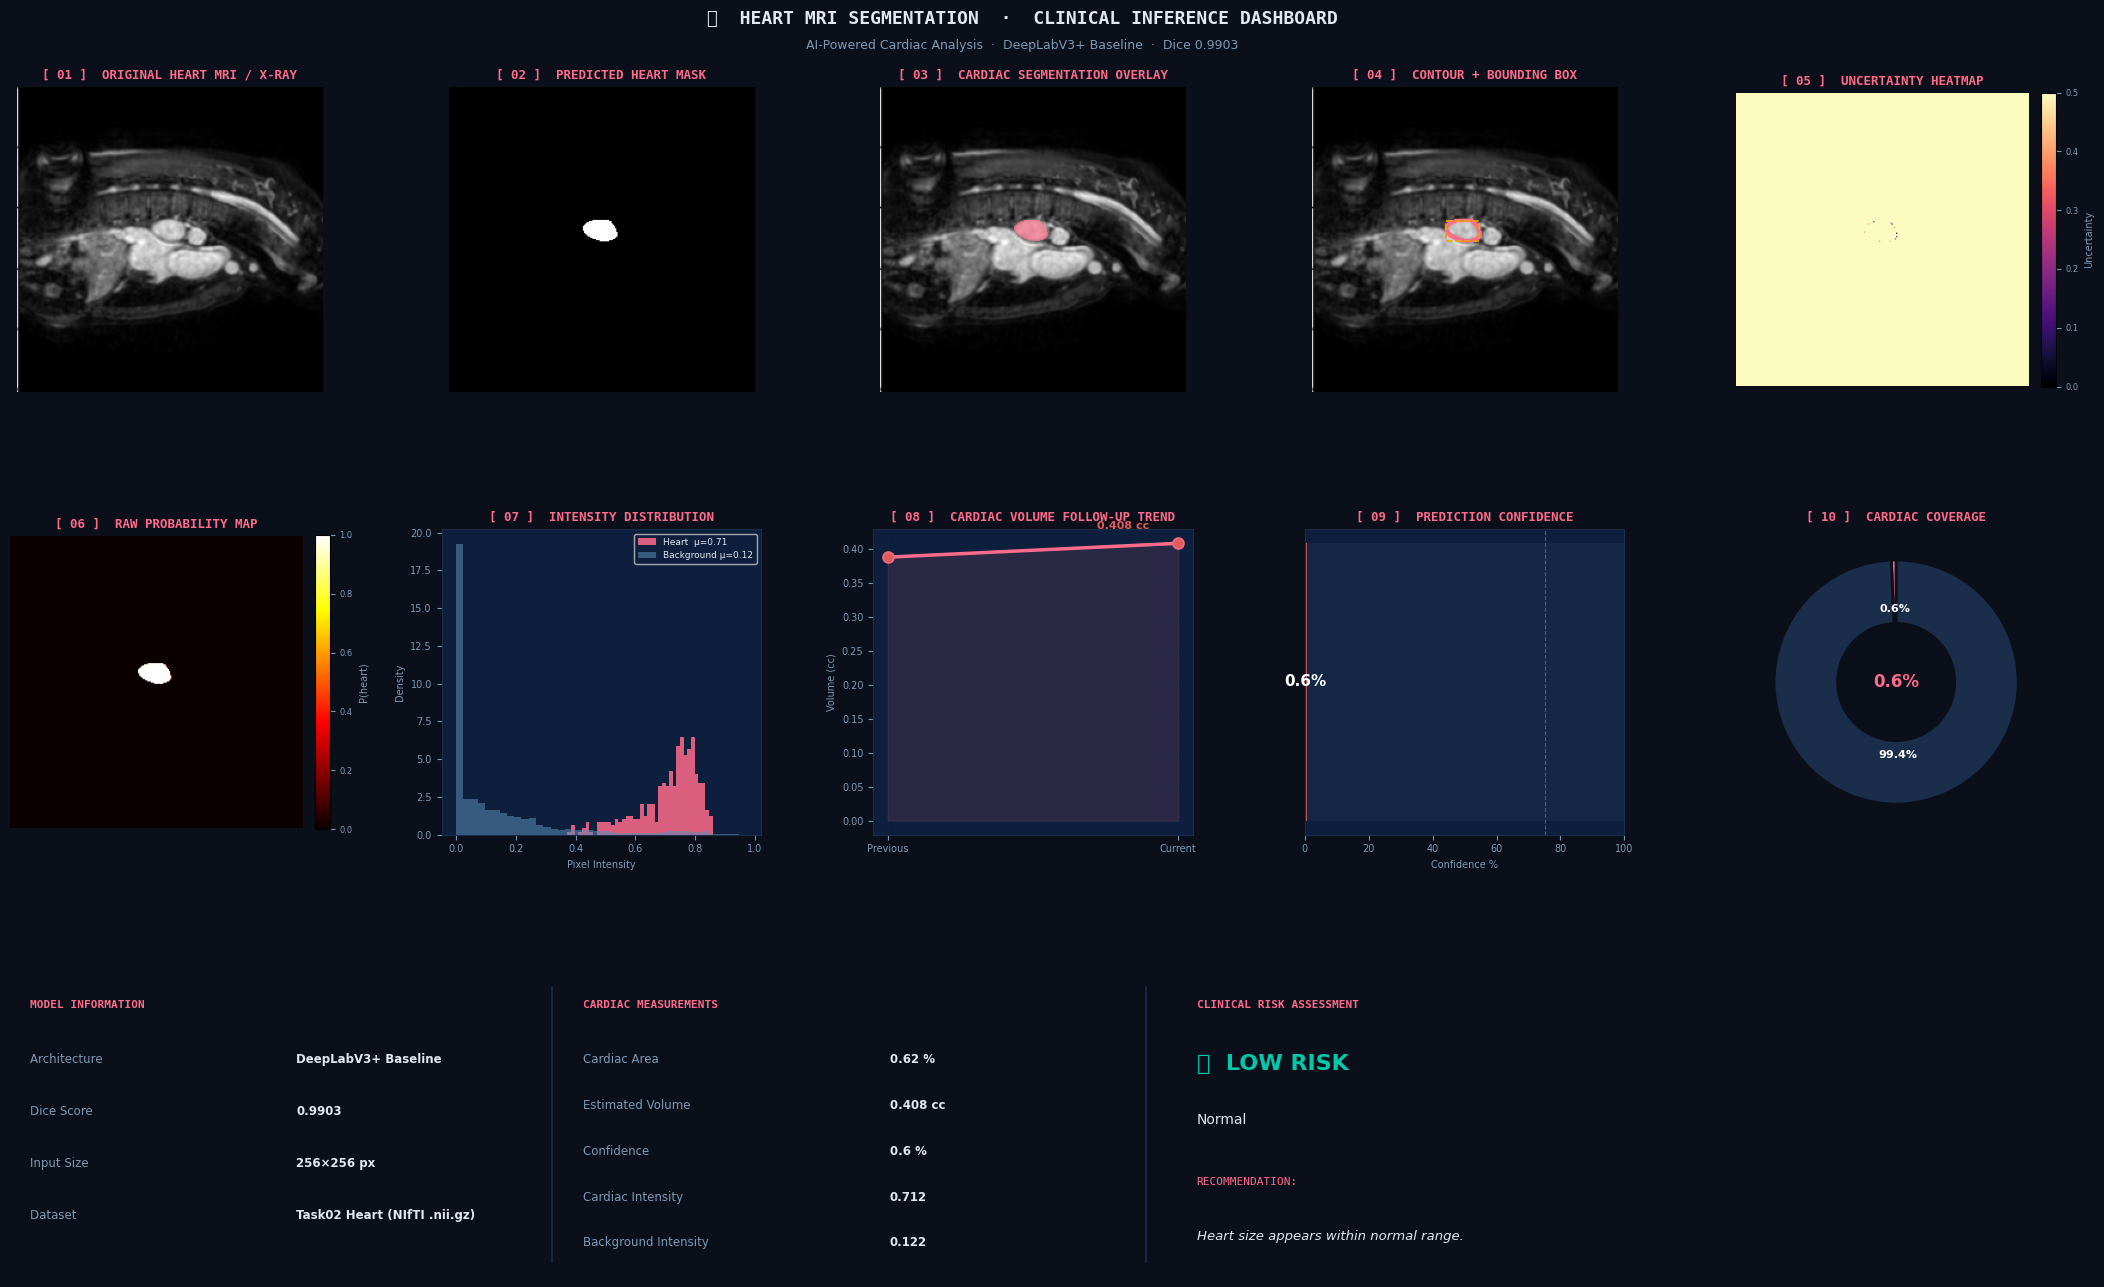

✅ Dashboard saved → /content/heart_clinical_report.png


In [9]:
from google.colab import files

# ── YOUR ORIGINAL upload logic ────────────────────────────────────────────────
uploaded      = files.upload()
uploaded_file = list(uploaded.values())[0]

# YOUR ORIGINAL single stream approach
uploaded_stream = io.BytesIO(uploaded_file)

print(f"\n📂 File received — running inference...")

img, mask, pred = run_heart_inference(uploaded_stream)
show_heart_clinical_dashboard(img, mask, pred)


## Step 6 · Download Clinical Report

In [10]:
from google.colab import files

files.download('/content/heart_clinical_report.png')
print("📥 Heart clinical report downloaded.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Heart clinical report downloaded.
